Finding boulders that were rated highly specifically by women



1.   API call to Mountain Project for boulders in a specific region

2.   For each boulder problem, pull out the user stars, ticks, and grade ratings. 

3.   Combine the above dataframes into one that includes all of the information for that boulder problem. 

4.   Once that has been completed, repeat for all boulder problems. 

5.   Use the combined dataframe for all boulder problems to find the user ID and name of all unique relevant users. 

6.   Pull the user data and make a user personal information database. 

7.   Combine the boulder problem database wtih the user information database. 

8.   Now all of the data is processed together, so I can start analyzing it. 

* How much information do I have on users? How many are missing data, etc
* How well am I guessing the gender of users?  I think the guesser is biased towards names of European descent.
* For each boulder problem, Display rating for overall, male, female, undetermined. 
* Also pull out dataframe of comments from women.
* Do I want to use AI to guess user gender from their comments attached to their ticks?





In [54]:
# Import packages
from bs4 import BeautifulSoup # https://beautiful-soup-4.readthedocs.io/en/latest/
import copy
from datetime import datetime
import gender_guesser.detector as gender
import io
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import requests # https://requests.readthedocs.io/en/latest/
import time


In [ ]:
# Define functions

def retrieve_overview_csv(URL):
  """
  This function is designed to work with the output of "Route Finder" on 
  Mountain Project. The URL corresponds to the Mountain project page that has
  a "Export CSV" button at the top. 

  Args:
      URL: This is the URL of the webpage. Type is string. 

  Returns:
      return_type: pandas dataframe
  """

  csv_export_request = requests.get(URL)

  if csv_export_request.status_code == 200:
    csv_df = pd.read_csv(io.StringIO(csv_export_request.text))
    print("CSV converted to pandas df")
  else:
    print("Something went wrong. Status code is: " + str(csv_export_request.status_code))


  csv_df[['Route Grade', 'Route Danger Rating']] = csv_df['Rating'].str.split(' ', expand=True)

  return csv_df


def get_route_URL(URL):
  """
  This function takes the URL of a specific climb and converts it to the URL 
  for the climbing statistics page. 

  Args:
      URL: This is the URL to the Mountain Project page for this climb. The type
      is string. 
      

  Returns:
      return_type: This is the URL to the Mountain Project stats page for this 
      climb. The type is string.  
  """

  substring = "/route/"
  text_to_insert = "stats/"
  return URL.replace(substring, substring + text_to_insert)



def get_route_stats(URL, stat_type, params = {'per_page': '250','page': '1',}, retries = 3, backoff = 2):
  """
  This function takes the URL of a specific climb and converts it to the URL 
  used to request the specified table on the route stats page.  

  Args:
      URL: This is the URL to the Mountain Project page for this climb. The type
           is string. 
      stat_type: This is the stat type that is requested. 
      params: Dictionary of parameters for the requested data. Default setting 
              is the default setting from MountainProject.
      

  Returns:
      return_type: This is a pandas dataframe of the requested route stat info.
      The type is pandas dataframe.  
  """
  prefix = "https://www.mountainproject.com/api/v2/routes/"
  
  if stat_type in ['stars', 'ratings', 'ticks', 'todos']:
    req_URL = prefix + URL.split('/')[-2] + "/" + stat_type
    for attempt in range(retries):
    response = requests.get(req_URL, params=params)
    if response.status_code != 200 or not response.text.strip():
      print(f"Warning: bad response ({response.status_code}) for {req_URL}. Returning empty DataFrame.")
      return pd.DataFrame()
    return pd.json_normalize(response.json()['data'])

  else:
    print("This is not an accepted stat_type request.\
          \nTry 'stars', 'ratings', 'ticks', or 'todos'.")
    return pd.DataFrame()
  


def create_route_stats_df(route_name, star_df, rating_df, tick_df, prefix_col = ['id', 'date', 'createdAt', 'updatedAt']):
  """
  This function is designed to work with function fill_area_df_with_stats. It takes as input
  the individual stats dataframes for the specificed route, adds prefix's to unique columns that 
  share names across dataframes and performs a merge to create a dataframe that includes all of
  the stats. 


  Args:
      route_name: This is the name of the route, as listed on Mountain Project. Type is string.
      star_df: This is the dataframe of the star stats for this route. Type is pandas dataframe. 
      rating_df: This is the dataframe of the difficulty ratings for this route. Type is pandas dataframe.
      tick_df: This is the dataframe of user ticks and comments for this route. Type is pandas dataframe.
      prefix_col:   This is the list of columns that need a prefix indicating what stat dataframe this column
                    is affiliated with before the stat dataframes are merged together.


  Returns:
      return_type:  pandas dataframe. This is the combined stats for an individual climbing
                    route. route_stas_df.
  """ 
  # Prepare star_df for merge
  star_df.columns = [f'star_{i}' if i in prefix_col else f'{i}' for i in star_df.columns]

  # Prepare rating_df for merge
  cols_to_drop = rating_df.columns[(rating_df == 0).all()]
  rating_df.drop(columns=cols_to_drop, inplace = True)
  rating_df.columns = [f'rating_{i}' if i in prefix_col else f'{i}' for i in rating_df.columns]

  # Prepare tick_df for merge
  if 'user.id' in tick_df.columns:
    tick_df.dropna(subset=['user.id'], inplace = True)
    tick_df['user.id'] = tick_df['user.id'].astype('Int64')
  if 'comment' in tick_df.columns:
    #tick_df['comment'] = tick_df['text'].str.split(".", n = 1, expand = True).iloc[:, 1:]
    tick_df['comment'] = tick_df['text'].str.split(".", n = 1, expand = True).get(1)
  cols_to_drop = ['user', 'text']
  for item in cols_to_drop[:]:
    if item not in tick_df.columns:
      cols_to_drop.remove(item)
  if cols_to_drop != []:
    tick_df.drop(columns=cols_to_drop, inplace = True)
  tick_df.columns = [f'tick_{i}' if i in prefix_col else f'{i}' for i in tick_df.columns]


  # merge with csv_df (aka overall route df)
  # Ensure empty DataFrames have at least the shared join columns so merge doesn't fail
  for df in [star_df, rating_df, tick_df]:
    for col in ['user.id', 'user.name']:
      if col not in df.columns:
        df[col] = pd.Series(dtype='object')
  route_stats_df = star_df.merge(rating_df, how = 'outer').merge(tick_df, how = 'outer')
  route_stats_df['user.id'] = route_stats_df['user.id'].astype('Int64')
  route_stats_df['Route'] = route_name

  return route_stats_df


def fill_area_df_with_stats(area_df):
  """
  This function takes the overview pandas dataframe of a climbing area (the output of retrieve_overview_csv)
  and performs a request for each climbing route to retrieve the stats regarding stars, ratings, and ticks 
  for that route using the get_route_stats function. Once stats for all routes have been retrieved, they 
  are merged with the area overview dataframe and this resulting dataframe is returned. 



  Args:
      area_df:  Type is pandas dataframe. Overview of the climbing area as downloaded from Mountain project
                using function retrieve_overview_csv. 
      

  Returns:
      return_type:  Pandas dataframe. This is the original input dataframe, now merged
                    with stats(stars, ratings, and ticks) of each route.  
  """
  route_dict = {}

  for i in range(0, len(area_df)):
      route_dict.update({area_df.iat[i,0]: get_route_URL(area_df.iat[i,2])})
  print(route_dict)
  all_routes_stats_df = pd.DataFrame(columns = ['star_id', 'score', 'star_createdAt', 'star_updatedAt', 'user.id',
                                                'user.name', 'rating_id', 'allRatings', 'boulderRating', 'safteyRating',
                                                'rating_createdAt', 'rating_updatedAt', 'tick_id', 'tick_date',
                                                'comment', 'style', 'leadStyle', 'pitches', 'tick_createdAt',
                                                'tick_updatedAt', 'Route']).astype({'user.id': 'Int64'})
  for keys in route_dict.keys():
      print('starting on ' + keys)
      star_df = get_route_stats(URL = route_dict[keys], stat_type = "stars", params = {'per_page': '250','page': '1'})
      print('made star_df')
      rating_df = get_route_stats(URL = route_dict[keys], stat_type = 'ratings', params = {'per_page': '250','page': '1'})
      print('made rating_df')
      tick_df = get_route_stats(URL = route_dict[keys], stat_type = 'ticks', params = {'per_page': '250','page': '1'})
      print('made tick_df')
      route_stats_df = create_route_stats_df(route_name = keys, 
                                             star_df = star_df, 
                                             rating_df = rating_df, 
                                             tick_df= tick_df, 
                                             prefix_col = ['id', 'date', 'createdAt', 'updatedAt'])
      print("made route_stats_df")
      all_routes_stats_df = pd.concat([all_routes_stats_df, route_stats_df])
      print("Finished updating all_routes_stats_df with stats from " + route_dict[keys])
  return all_routes_stats_df
 


      
    
  


def user_apply_func(x):
    '''
    This functions is designed to apply row-by-row to a pandas dataframe. 
    It takes as input the dataframe of all relevant users (listing their user ID and username) and initiates the individual user dicitonary.
    '''
    # initiate dictionary
    user_dict = dict.fromkeys(['user_ID', 'user_name', 'user_URL', 'request_date', 'location', 'age_at_request_date', 'listed_gender', 'guessed_gender'])
    # fill the dictionary values
    user_dict['user_ID'] = x['user.id']
    user_dict['user_name'] = x['user.name']
    return user_dict


# Probably don't need this...
# def compile_all_user_dict(star_df, rating_df, tick_df, shared_col = ['user.id', 'user.name']):
#   """
#     This function takes the combined data frame (?) or list of relevant data frames(?)
#     and makes a list(?) of all of the user names/user IDs. Probably make dictionary
#     of user ID as key and a nested dictionary of ID and name.  

#     Args:
#         star_df: 
#         rating_df
#         tick_df
#         shared_col
        

#     Returns:
#         return_type: This is a nested dictionary of user IDs as top level keys 
#         and user names and other information as nested keys. 
#   """
  
#   unique_user_df = star_df.merge(rating_df, how = 'outer', on = shared_col).merge(tick_df, how = 'outer', on = shared_col)[shared_col].dropna().drop_duplicates()

#   unique_user_df['user.id'] = unique_user_df['user.id'].astype(int)

#   unique_user_df['user_dict'] = unique_user_df.apply(user_apply_func, axis = 1)

#   unique_user_df.set_index('user.id', inplace = True)
#   all_user_dict = unique_user_df[['user_dict']].iloc[:, 0].to_dict()
#   return all_user_dict

  
  



def get_user_info(user_dict):
  """
  This function takes the dictionary of an individual user, containing their
  user ID and name. It returns the dictionary of an individual user updated with
  the age of the user at time of request, the date of data request, the 
  user's gender, and the user's location of residence. 


  Args:
      user_dict:
      

  Returns:
      return_type: a dictionary of user information. 
      {user_ID, user_name, listed_gender, guessed_gender, age_at_request_date, 
       request_date, location}
  """

  # user_dict['user_ID'] = "201730853"
  # user_dict['user_name'] = "Corey Stegall"

  user_dict['user_URL'] = "https://www.mountainproject.com/user/" + str(user_dict['user_ID']) + "/" + user_dict['user_name'].lower().replace(" ", "-")


  page = requests.get(user_dict['user_URL']) # Step 1: get the page content
  soup = BeautifulSoup(page.text, 'html.parser')

  lines = soup.find_all("div", class_ = "")

  line_list = []
  for line in lines:
    if line.get_text().strip() != '':
      line_list.append(line.get_text().strip())

  #print(line_list)


  if len(line_list) > 0:
    line_list = line_list[0].replace("  ", "").split('\n')
    print("line_list exists")
  else:
    print("line_list is empty")

  #print(line_list)


  for i in range(0, len(line_list)):
    if len(line_list[i]) < 3:
      continue
    elif "years old" in line_list[i]:
      user_dict['age_at_request_date'] = int(line_list[i].split()[0])
    elif line_list[i] in ('Male', 'Female'):
      user_dict['listed_gender'] = line_list[i]
    else:
      user_dict['location'] = line_list[i]

    user_dict['request_date'] = datetime.now().year


    
  user_dict["guessed_gender"] = gender.Detector().get_gender(user_dict['user_name'].split(" ")[0].title())




  return user_dict



    









In [50]:

# Go to Mountain Project and navigate to climbing area of interest. Open the Find routes button and filter for all routes of interest. 
# In the original use case, filter for all boulder problems. 
URL = "https://www.mountainproject.com/route-finder-export?diffMaxaid=75260&diffMaxboulder=21700&diffMaxice=38500&diffMaxmixed=65050&diffMaxrock=5500&diffMinaid=70000&diffMinboulder=20000&diffMinice=30000&diffMinmixed=50000&diffMinrock=1800&is_sport_climb=1&is_top_rope=1&is_trad_climb=1&pitches=0&selectedIds=105716862&sort1=area&sort2=rating&stars=0&type=boulder&viewAll=1"

csv_df = retrieve_overview_csv(URL)

CSV converted to pandas df


In [51]:
# for testing, use just the head of the resulting csv. 
#csv_df = csv_df.head(100)

In [ ]:
csv_df.to_csv("20260328_")

,Route,Location,URL,Avg Stars,Your Stars,Route Type,Rating,Pitches,Length,Area Latitude,Area Longitude,Route Grade,Route Danger Rating
39,schizzle,Titanic Boulder > Big Bend Bouldering Area > R...,https://www.mountainproject.com/route/10628048...,3.0,-1,Boulder,V5-,1,14.0,38.6276,-109.4966,V5-,None


In [47]:
all_routes_stats_df = fill_area_df_with_stats(area_df = csv_df)

{'Death Flakes': 'https://www.mountainproject.com/route/stats/114444130/death-flakes', 'Rampage': 'https://www.mountainproject.com/route/stats/106135567/rampage', 'Press tight': 'https://www.mountainproject.com/route/stats/112359419/press-tight', 'The Grim Reacher': 'https://www.mountainproject.com/route/stats/106135578/the-grim-reacher', 'Circus Trick': 'https://www.mountainproject.com/route/stats/105717433/circus-trick', 'Circus Trick Right': 'https://www.mountainproject.com/route/stats/106127755/circus-trick-right', 'Chaos': 'https://www.mountainproject.com/route/stats/106013793/chaos', 'Hell Belly Stand': 'https://www.mountainproject.com/route/stats/107957139/hell-belly-stand', 'Grim Reacher Direct': 'https://www.mountainproject.com/route/stats/109990646/grim-reacher-direct', 'Phantom Fighter (Stand)': 'https://www.mountainproject.com/route/stats/109990741/phantom-fighter-stand', 'Hell Belly': 'https://www.mountainproject.com/route/stats/106379808/hell-belly', 'Phantom Fighter': 'h

/tmp/ipykernel_36548/4135669340.py:182: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_routes_stats_df = pd.concat([all_routes_stats_df, route_stats_df])


made star_df
made rating_df
made tick_df
made route_stats_df
Finished updating all_routes_stats_df with stats from https://www.mountainproject.com/route/stats/106135567/rampage
starting on Press tight
made star_df
made rating_df
made tick_df
made route_stats_df
Finished updating all_routes_stats_df with stats from https://www.mountainproject.com/route/stats/112359419/press-tight
starting on The Grim Reacher
made star_df
made rating_df
made tick_df
made route_stats_df
Finished updating all_routes_stats_df with stats from https://www.mountainproject.com/route/stats/106135578/the-grim-reacher
starting on Circus Trick
made star_df
made rating_df
made tick_df
made route_stats_df
Finished updating all_routes_stats_df with stats from https://www.mountainproject.com/route/stats/105717433/circus-trick
starting on Circus Trick Right
made star_df
made rating_df
made tick_df
made route_stats_df
Finished updating all_routes_stats_df with stats from https://www.mountainproject.com/route/stats/106127

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [8]:

area_df = csv_df.merge(all_routes_stats_df, how = 'left')
area_df['user.id'] = area_df['user.id'].astype('Int64')

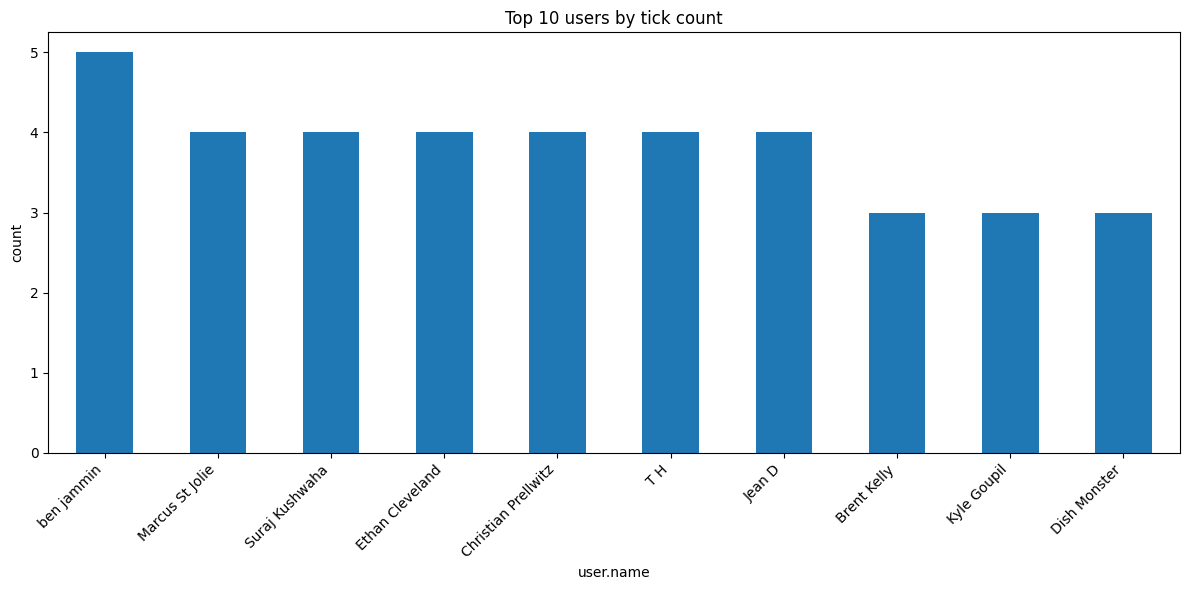

Total unique users: 372
user.name
ben jammin             5
Marcus St Jolie        4
Suraj Kushwaha         4
Ethan Cleveland        4
Christian Prellwitz    4
T H                    4
Jean D                 4
Brent Kelly            3
Kyle Goupil            3
Dish Monster           3
Name: count, dtype: int64


In [ ]:




vc = area_df['user.name'].value_counts()
top_n = 10

fig, ax = plt.subplots(figsize=(12, 6))
vc.head(top_n).plot(kind='bar', ax=ax)
ax.set_title(f'Top {top_n} users by tick count')
ax.set_xlabel('user.name')
ax.set_ylabel('count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f'Total unique users: {vc.shape[0]}')
print(vc.head(10))

In [ ]:
# route_URL = get_route_URL(csv_df.iat[0, 2])

route_dict = {}

for i in range(0, len(csv_df)-1):
  route_dict.update({csv_df.iat[i,0]: get_route_URL(csv_df.iat[i,2])})


In [ ]:
# for i in route_dict.keys():
#     print(i)

Death Flakes
Rampage
Press tight
The Grim Reacher
Circus Trick
Circus Trick Right
Chaos
Hell Belly Stand
Grim Reacher Direct
Phantom Fighter (Stand)
Hell Belly
Phantom Fighter
Back Alley
Back Alley Left
Center Start
Slots of Fun
Arete Left Side
Center Direct
Traverse Slots
Arete Right Side
Shorter Traverse
Bum Steer
Arete Left Side Sit Start
Blue Light
Kick Start
Leftover Lover
The Crimp Challenge
Lip Traverse
The Pregnancy Arete
Mr. Trujillo's Big Day
Kick Start Low
Silly Wabbit
Dyno for Dollars
Double Crimp
1000 LB Caboose
Unknown
Sticky's Arete
Shot Hole Traverse
Skinless Dyno
schizzle
Satya
Space Needle
LSD Saint
Slopey
Descent
Block Shock
Block Pock
Brown Power
Squashed Arete
Block Party
Slappin the Block
Whodunnit
Slappin' The Block Sit Start
Five Finger DIscount
Eric's
Short Stuff
Mueve se!
The Punisher
La Derecha
Blankety Stand
La Derecha SDS
Blankety Blank
Washing Machine
Unnamed V3
Washed Up
Washed Up Extension
Hueco Finish
Upwardly Mobile (AKA Hueco Cranks)
Hueco Traverse
Wu

In [ ]:
# I might want to update this, to use the combined stats df as the input....tbd
all_user_dict = compile_all_user_dict(star_df, rating_df, tick_df, shared_col = ['user.id', 'user.name'])

In [71]:
all_user_dict

{10795: {'user_ID': 10795,
  'user_name': 'Craig Quincy',
  'user_URL': None,
  'request_date': None,
  'location': None,
  'age_at_request_date': None,
  'listed_gender': None,
  'guessed_gender': None},
 105841142: {'user_ID': 105841142,
  'user_name': 'kzoo',
  'user_URL': None,
  'request_date': None,
  'location': None,
  'age_at_request_date': None,
  'listed_gender': None,
  'guessed_gender': None},
 106196136: {'user_ID': 106196136,
  'user_name': 'Ivano Del Piccolo',
  'user_URL': None,
  'request_date': None,
  'location': None,
  'age_at_request_date': None,
  'listed_gender': None,
  'guessed_gender': None},
 106201630: {'user_ID': 106201630,
  'user_name': 'ben jammin',
  'user_URL': None,
  'request_date': None,
  'location': None,
  'age_at_request_date': None,
  'listed_gender': None,
  'guessed_gender': None},
 106484139: {'user_ID': 106484139,
  'user_name': 'Brian Koralewski',
  'user_URL': None,
  'request_date': None,
  'location': None,
  'age_at_request_date': No

In [ ]:
# updates user info dictionary
for key in all_user_dict.keys():
    get_user_info(user_dict = all_user_dict[key])

line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is

In [77]:
all_user_dict

{10795: {'user_ID': 10795,
  'user_name': 'Craig Quincy',
  'user_URL': 'https://www.mountainproject.com/user/10795/craig-quincy',
  'request_date': 2026,
  'location': 'Louisville, CO',
  'age_at_request_date': None,
  'listed_gender': 'Male',
  'guessed_gender': 'male'},
 105841142: {'user_ID': 105841142,
  'user_name': 'kzoo',
  'user_URL': 'https://www.mountainproject.com/user/105841142/kzoo',
  'request_date': 2026,
  'location': 'michigan',
  'age_at_request_date': 48,
  'listed_gender': 'Male',
  'guessed_gender': 'unknown'},
 106196136: {'user_ID': 106196136,
  'user_name': 'Ivano Del Piccolo',
  'user_URL': 'https://www.mountainproject.com/user/106196136/ivano-del-piccolo',
  'request_date': None,
  'location': None,
  'age_at_request_date': None,
  'listed_gender': None,
  'guessed_gender': 'male'},
 106201630: {'user_ID': 106201630,
  'user_name': 'ben jammin',
  'user_URL': 'https://www.mountainproject.com/user/106201630/ben-jammin',
  'request_date': 2026,
  'location': 'M

In [14]:
# maybe combine ratings, ticks, and stars tables, get a list (or dictionary?) of
# all of the users with user ID, user name, and then add the line_list of user
# location, age, and gender information. 

# This dicitonary can then be turned into a pandas dataframe and then get merged
# with the other data. 

In [ ]:
# unique_user_df = star_df.merge(rating_df, how = 'outer', on = ['user.id', 'user.name']).merge(tick_df, how = 'outer', on = ['user.id', 'user.name'])[['user.id', 'user.name']].dropna().drop_duplicates()

# unique_user_df['user.id'] = unique_user_df['user.id'].astype(int)

# unique_user_df['user_dict'] = unique_user_df.apply(user_apply_func, axis = 1)

# unique_user_df.set_index('user.id', inplace = True)
# all_user_dict = unique_user_df[['user_dict']].iloc[:, 0].to_dict()

In [11]:
unique_user_df = (
    area_df[['user.id', 'user.name']]
    .dropna()
    .drop_duplicates()
    .copy()
)
unique_user_df['user.id'] = unique_user_df['user.id'].astype(int)
unique_user_df['user_dict'] = unique_user_df.apply(user_apply_func, axis=1)
unique_user_df.set_index('user.id', inplace=True)
all_user_dict = unique_user_df['user_dict'].to_dict()

print(f"Unique users found: {len(all_user_dict)}")

Unique users found: 372


In [12]:
for key in all_user_dict.keys():
    get_user_info(user_dict=all_user_dict[key])

line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is empty
line_list is

In [13]:
user_info_df = pd.DataFrame(all_user_dict.values())
print(user_info_df.shape)
user_info_df.head()

(372, 8)


,user_ID,user_name,user_URL,request_date,location,age_at_request_date,listed_gender,guessed_gender
0,10795,Craig Quincy,https://www.mountainproject.com/user/10795/cra...,2026.0,"Louisville, CO",NaN,Male,male
1,105841142,kzoo,https://www.mountainproject.com/user/105841142...,2026.0,michigan,48.0,Male,unknown
2,106196136,Ivano Del Piccolo,https://www.mountainproject.com/user/106196136...,NaN,None,NaN,None,male
3,106201630,ben jammin,https://www.mountainproject.com/user/106201630...,2026.0,"Moab, UT",40.0,Male,male
4,106484139,Brian Koralewski,https://www.mountainproject.com/user/106484139...,2026.0,"Springville, UT",NaN,Male,male


In [10]:
user_info_df = pd.read_csv("20260328_user_info_df.csv")

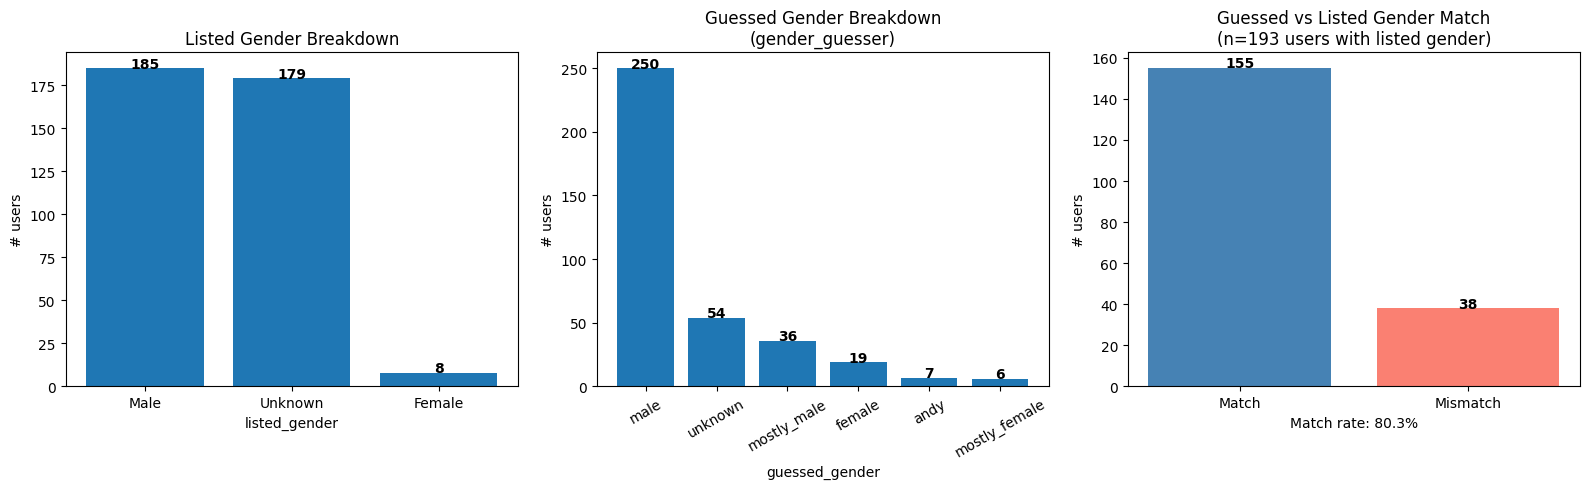

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Plot 1: listed_gender breakdown ---
listed_counts = user_info_df['listed_gender'].fillna('Unknown').value_counts()
axes[0].bar(listed_counts.index, listed_counts.values)
axes[0].set_title('Listed Gender Breakdown')
axes[0].set_xlabel('listed_gender')
axes[0].set_ylabel('# users')
for i, v in enumerate(listed_counts.values):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

# --- Plot 2: guessed_gender breakdown ---
guessed_counts = user_info_df['guessed_gender'].fillna('unknown').value_counts()
axes[1].bar(guessed_counts.index, guessed_counts.values)
axes[1].set_title('Guessed Gender Breakdown\n(gender_guesser)')
axes[1].set_xlabel('guessed_gender')
axes[1].set_ylabel('# users')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(guessed_counts.values):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

# --- Plot 3: guessed vs listed match rate ---
# Only compare users who have a listed gender
has_listed = user_info_df.dropna(subset=['listed_gender', 'guessed_gender']).copy()

# Normalize: map guessed_gender to Male/Female for comparison
guess_map = {
    'male': 'Male', 'mostly_male': 'Male',
    'female': 'Female', 'mostly_female': 'Female',
    'andy': 'Unknown', 'unknown': 'Unknown'
}
has_listed['guessed_normalized'] = has_listed['guessed_gender'].map(guess_map).fillna('Unknown')
has_listed['match'] = has_listed['listed_gender'] == has_listed['guessed_normalized']

match_counts = has_listed['match'].value_counts()
match_labels = ['Match' if k else 'Mismatch' for k in match_counts.index]
axes[2].bar(match_labels, match_counts.values, color=['steelblue', 'salmon'])
axes[2].set_title(f'Guessed vs Listed Gender Match\n(n={len(has_listed)} users with listed gender)')
axes[2].set_ylabel('# users')
for i, v in enumerate(match_counts.values):
    axes[2].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

match_rate = has_listed['match'].mean()
axes[2].set_xlabel(f'Match rate: {match_rate:.1%}')

plt.tight_layout()
plt.show()

In [12]:
area_df = area_df.merge(
    user_info_df[['user_ID', 'user_URL', 'location', 'age_at_request_date', 'listed_gender', 'guessed_gender']],
    left_on='user.id',
    right_on='user_ID',
    how='left'
).drop(columns='user_ID')

area_df.head()

,Route,Location,URL,Avg Stars,Your Stars,Route Type,Rating,Pitches,Length,Area Latitude,...,style,leadStyle,pitches,tick_createdAt,tick_updatedAt,user_URL,location,age_at_request_date,listed_gender,guessed_gender
0,Death Flakes,Chaos Boulder > Big Bend Bouldering Area > Riv...,https://www.mountainproject.com/route/11444413...,3.0,-1,Boulder,V1 R,1,20.0,38.65058,...,,,1.0,2025-04-09T04:29:09.000000Z,2025-04-09T04:29:09.000000Z,https://www.mountainproject.com/user/10795/cra...,"Louisville, CO",NaN,Male,male
1,Death Flakes,Chaos Boulder > Big Bend Bouldering Area > Riv...,https://www.mountainproject.com/route/11444413...,3.0,-1,Boulder,V1 R,1,20.0,38.65058,...,Attempt,,1.0,2023-04-02T23:11:53.000000Z,2023-04-02T23:11:53.000000Z,https://www.mountainproject.com/user/10795/cra...,"Louisville, CO",NaN,Male,male
2,Death Flakes,Chaos Boulder > Big Bend Bouldering Area > Riv...,https://www.mountainproject.com/route/11444413...,3.0,-1,Boulder,V1 R,1,20.0,38.65058,...,Lead,Onsight,1.0,2021-03-31T00:57:57.000000Z,2021-03-31T00:57:57.000000Z,https://www.mountainproject.com/user/105841142...,michigan,48.0,Male,unknown
3,Death Flakes,Chaos Boulder > Big Bend Bouldering Area > Riv...,https://www.mountainproject.com/route/11444413...,3.0,-1,Boulder,V1 R,1,20.0,38.65058,...,,,1.0,2019-05-16T18:55:03.000000Z,2019-05-16T18:55:03.000000Z,https://www.mountainproject.com/user/106196136...,NaN,NaN,NaN,male
4,Death Flakes,Chaos Boulder > Big Bend Bouldering Area > Riv...,https://www.mountainproject.com/route/11444413...,3.0,-1,Boulder,V1 R,1,20.0,38.65058,...,NaN,NaN,NaN,NaN,NaN,https://www.mountainproject.com/user/106201630...,"Moab, UT",40.0,Male,male


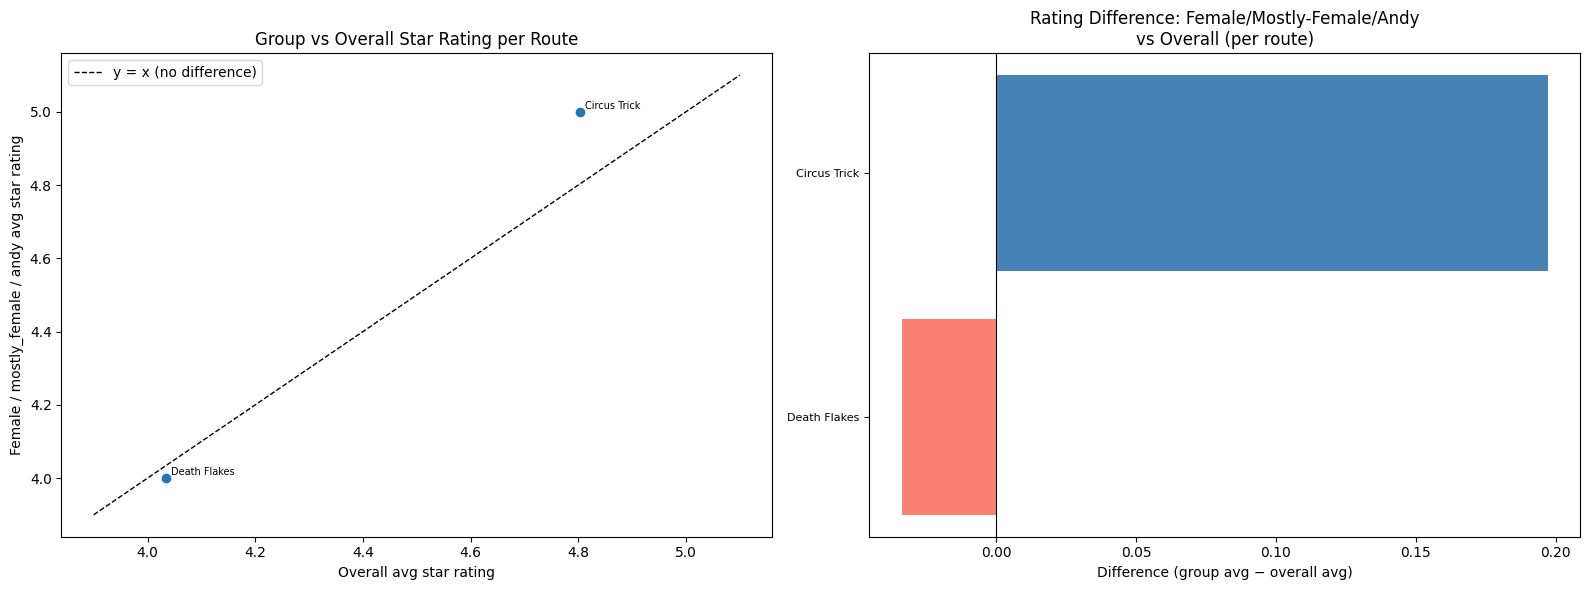

              overall_avg  group_avg  diff
Route                                     
Death Flakes         4.03        4.0 -0.03
Circus Trick         4.80        5.0  0.20


In [ ]:


target_genders = ['female', 'mostly_female', 'andy']

# Per-route averages
overall_avg = area_df.groupby('Route')['score'].mean().rename('overall_avg')
group_avg = (
    area_df[area_df['guessed_gender'].isin(target_genders)]
    .groupby('Route')['score'].mean()
    .rename('group_avg')
)

compare_df = pd.concat([overall_avg, group_avg], axis=1).dropna()
compare_df['diff'] = compare_df['group_avg'] - compare_df['overall_avg']
compare_df = compare_df.sort_values('overall_avg')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Scatter — group avg vs overall avg per route ---
ax = axes[0]
ax.scatter(compare_df['overall_avg'], compare_df['group_avg'], zorder=3)
lims = [
    min(compare_df['overall_avg'].min(), compare_df['group_avg'].min()) - 0.1,
    max(compare_df['overall_avg'].max(), compare_df['group_avg'].max()) + 0.1,
]
ax.plot(lims, lims, 'k--', linewidth=1, label='y = x (no difference)')
for route, row in compare_df.iterrows():
    ax.annotate(route, (row['overall_avg'], row['group_avg']),
                fontsize=7, textcoords='offset points', xytext=(4, 2))
ax.set_xlabel('Overall avg star rating')
ax.set_ylabel('Female / mostly_female / andy avg star rating')
ax.set_title('Group vs Overall Star Rating per Route')
ax.legend()

# --- Plot 2: Difference bar chart (group_avg - overall_avg) ---
ax = axes[1]
colors = ['salmon' if d < 0 else 'steelblue' for d in compare_df['diff']]
bars = ax.barh(compare_df.index, compare_df['diff'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Difference (group avg − overall avg)')
ax.set_title('Rating Difference: Female/Mostly-Female/Andy\nvs Overall (per route)')
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

print(compare_df[['overall_avg', 'group_avg', 'diff']].round(2))

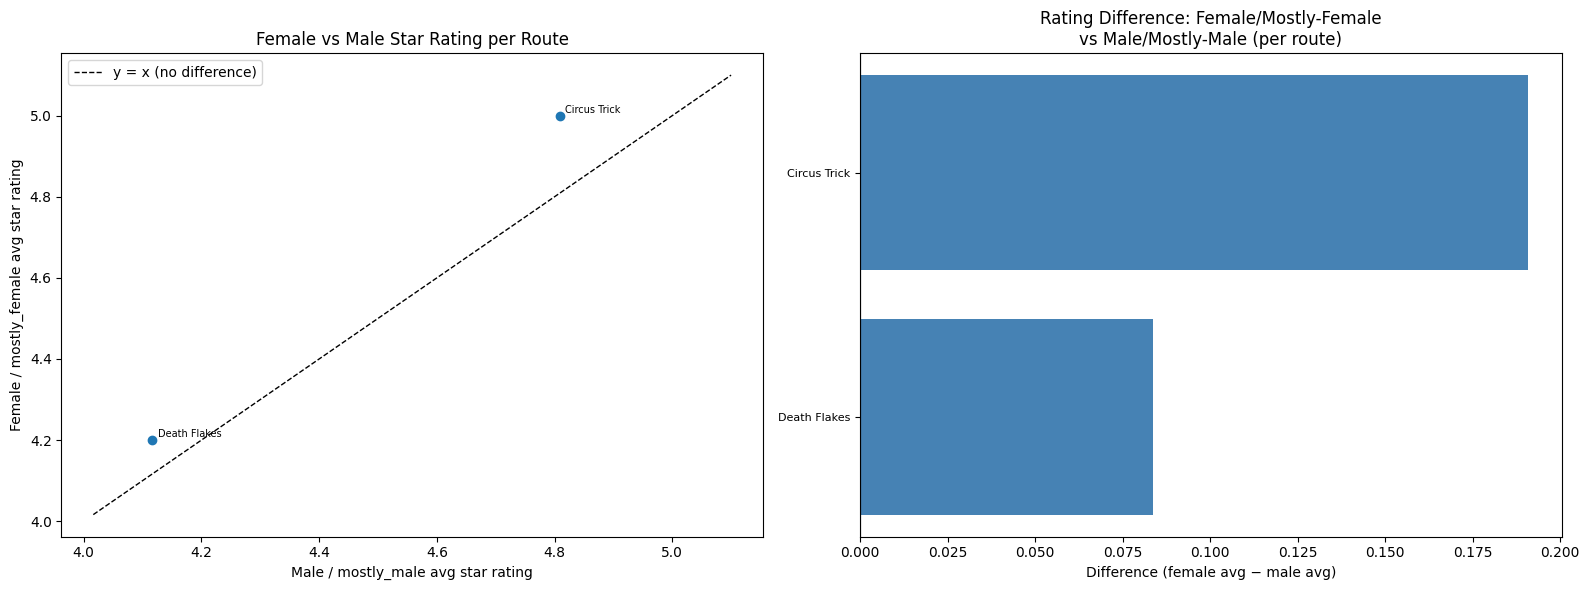

              female_avg  male_avg  diff
Route                                   
Death Flakes         4.2      4.12  0.08
Circus Trick         5.0      4.81  0.19


In [14]:
female_avg = (
    area_df[area_df['guessed_gender'].isin(['female', 'mostly_female'])]
    .groupby('Route')['score'].mean()
    .rename('female_avg')
)
male_avg = (
    area_df[area_df['guessed_gender'].isin(['male', 'mostly_male'])]
    .groupby('Route')['score'].mean()
    .rename('male_avg')
)

fm_df = pd.concat([female_avg, male_avg], axis=1).dropna()
fm_df['diff'] = fm_df['female_avg'] - fm_df['male_avg']
fm_df = fm_df.sort_values('male_avg')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Scatter ---
ax = axes[0]
ax.scatter(fm_df['male_avg'], fm_df['female_avg'], zorder=3)
lims = [
    min(fm_df['male_avg'].min(), fm_df['female_avg'].min()) - 0.1,
    max(fm_df['male_avg'].max(), fm_df['female_avg'].max()) + 0.1,
]
ax.plot(lims, lims, 'k--', linewidth=1, label='y = x (no difference)')
for route, row in fm_df.iterrows():
    ax.annotate(route, (row['male_avg'], row['female_avg']),
                fontsize=7, textcoords='offset points', xytext=(4, 2))
ax.set_xlabel('Male / mostly_male avg star rating')
ax.set_ylabel('Female / mostly_female avg star rating')
ax.set_title('Female vs Male Star Rating per Route')
ax.legend()

# --- Plot 2: Difference bar chart (female_avg - male_avg) ---
ax = axes[1]
colors = ['salmon' if d < 0 else 'steelblue' for d in fm_df['diff']]
ax.barh(fm_df.index, fm_df['diff'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Difference (female avg − male avg)')
ax.set_title('Rating Difference: Female/Mostly-Female\nvs Male/Mostly-Male (per route)')
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

print(fm_df[['female_avg', 'male_avg', 'diff']].round(2))